In [1]:
import os
from pathlib import Path
import requests
import io
from collections.abc import Iterable
from PIL import Image
from IPython.display import HTML
from tqdm.notebook import tqdm, trange

import torch
import torchvision.transforms.v2 as transforms
import torch.nn.functional as F
from scipy.optimize import differential_evolution

import numpy as np
import matplotlib.pyplot as plt

In [2]:
def select_target(inputs_dir):

    inputs_dir = Path(inputs_dir)
    images = [image for image in sorted(list(inputs_dir.iterdir())) if image.suffixes in [['.jpeg'], ['.jpg']]]
    random_number_generator = np.random.default_rng()
    image_path = random_number_generator.choice(images, size=1)[0]
    
    return image_path


In [3]:
def plot_figure(image):

    if (type(image) == torch.Tensor):
        shape = torch.tensor(image.shape)
        dimensions = len(shape)
        hw_indicies = torch.where(shape == input_size[0])[0]
        if (0 not in hw_indicies) and (dimensions == 3):
            permutation = torch.cat((hw_indicies, torch.tensor([0])))
            image = image.permute(permutation.tolist())

    plt.figure(figsize = (4.8, 4.8))
    plt.imshow(image)
    plt.axis('off')
    plt.show();
    

In [4]:
def make_prediction(image_tensor):

    # check normalization
    batch = image_tensor.permute(0, 2, 3, 1).flatten(0, 2)
    min_value, max_value = torch.aminmax(batch, dim = 0)    
    for channels in range(len(min_value)):
        min_possible = (0.0 - means[channels])/stdevs[channels]
        max_possible = (1.0 - means[channels])/stdevs[channels]
        if (min_value[channels] < min_possible) and (max_value[channels] > max_possible):
            print('Input not normalized appropriately')
            return torch.zeroslike(classes)

    image_tensor = image_tensor.to(device)
    with torch.no_grad():
        outputs = model(image_tensor)
        confidence, predicted_class = torch.max(outputs, 1)
    
    return classes[predicted_class.item()]

In [5]:
def perturb_image(pixels, image):

    #image processing pipelines
    discrete_downsample = transforms.Compose([
        transforms.Resize(input_size),
        transforms.ToTensor(),          # Converts to tensor and scales pixels to [0.0, 1.0]
        transforms.Lambda(lambda x: (x * 255)),
        transforms.ToDtype(torch.uint8, scale = False)
    ])
    continuous = transforms.Compose([
        transforms.ToDtype(torch.float32, scale=True)
        ])
    image = discrete_downsample(image)
        
    # At pixel's x,y position, assign its rgb value
    pixels = pixels.reshape(-1, 5)
    for pixel in pixels:
        x_pos, y_pos, *rgb = pixel
        x_pos, y_pos = [torch.clamp(torch.tensor(p), min = 0, max = input_size[0] - 1).long() for p in (x_pos, y_pos)]
        rgb = torch.Tensor(rgb)
        rgb = torch.clamp(rgb, min=0, max=255)
        image[:, x_pos, y_pos] = rgb
        
    image = continuous(image)
    
    return image

In [6]:
def objective_function(pixels, image, target):
    
    perturbed_image = perturb_image(pixels, image)
    normalize = transforms.Compose([
        transforms.Normalize(mean=means, 
                             std=stdevs)
    ])
    perturbed_image = normalize(perturbed_image)
    perturbed_image = perturbed_image.unsqueeze(0)
    perturbed_image = perturbed_image.to(device)
    
    with torch.no_grad():
        logits = model(perturbed_image)
        probabilities = F.softmax(logits, dim = 1)
    
    return -probabilities[0, target].cpu().item()
    

In [7]:
def n_pixel_attack(target, target_class, pixel_budget, maxiter = 50, population_size = 20):
    
    evolutionary_line = []
    generation_callback = Tracking(itterations = maxiter)
    bounds = [(0,input_size[0] - 1), (0,input_size[1] - 1), (0,255), (0,255), (0,255)] * pixel_budget
    try:
        result = differential_evolution(
            objective_function,
            bounds,
            args=(target, target_class),
            maxiter = maxiter,
            popsize = population_size,
            #strategy = 'rand2bin',
            callback=generation_callback,
        )
        evolutionary_line = generation_callback.parameter_history
    finally:
        generation_callback.close()
        
    return evolutionary_line

In [8]:
def tune_attack(target, target_class, search_steps = 5, pixel_budget = 10):

    yet_to_converge = True
    final_perturbation = None
    successful_history = None

    lower_bound = 1
    upper_bound = pixel_budget
    
    for step in trange(search_steps):
        evolutionary_line = n_pixel_attack(target, target_class, pixel_budget = pixel_budget)
        
        # apply perturbation
        final_mutation = evolutionary_line[-1]
        final_perturbation = perturb_image(final_mutation, target)
        normalize_tensor = model_normalize(final_perturbation)
        perturbed_image = normalize_tensor.unsqueeze(0)
        perturbed_image = perturbed_image.to(device)

        # check if attack was successful
        with torch.no_grad():
            logits = model(perturbed_image)
            probabilities = F.softmax(logits, dim = 1)
        confidence, predicted_class = torch.max(probabilities, 1)
        converged = (predicted_class == target_class)

        # tune pixel buget
        if (converged == True):
            yet_to_converge = False
            upper_bound = pixel_budget
            successful_history = evolutionary_line
        elif (converged == False) and (yet_to_converge == False):
            lower_bound = pixel_budget
        elif (converged == False) and (yet_to_converge == True):
            lower_bound = pixel_budget
            upper_bound *= 4

        if (lower_bound == upper_bound):
            break
        pixel_budget = int((upper_bound + lower_bound)/2)

    return successful_history
        

In [11]:
def animate_evolution(target_path, history, outputs_dir = outputs_dir):
    evolution_gif = []

    target = Image.open(target_path)
    target = downsample(target)

    for generation, mutation in enumerate(history):
        if np.NaN in mutation:
            npa = downsample(target)
        else:
            npa = perturb_image(mutation, target)
        
        normalize_tensor = model_normalize(npa)
        perturbed_image = normalize_tensor.unsqueeze(0)
        perturbed_image = perturbed_image.to(device)
        with torch.no_grad():
            logits = model(perturbed_image)
            probabilities = F.softmax(logits, dim = 1)
        confidence, predicted_class = torch.max(probabilities, 1)
        
        title = f"Generation: {generation}\nPredicted Class: {classes[predicted_class.item()]} with {confidence.item(): .3f} confidence\nTarget Class: {classes[target_class]} with {probabilities[0, target_class]: .3f} confidence"
        
        shape = torch.tensor(npa.shape)
        dimensions = len(shape)
        hw_indicies = torch.where(shape == input_size[0])[0]
        if (0 not in hw_indicies) and (dimensions == 3):
            permutation = torch.cat((hw_indicies, torch.tensor([0])))
            npa = npa.permute(permutation.tolist())
        
        plt.figure(figsize = (4.8, 4.8))
        plt.title(title, loc="left")
        plt.imshow(npa)
        plt.axis('off')
    
        # Convert the plot into an Image object
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight')
        plt.close()
        buf.seek(0)
        cam = Image.open(buf)
        evolution_gif.append(cam)
    
    outputs_dir = Path(outputs_dir)
    pixel_count = int(len(mutation)//5)
    filename = f"{target_path.name.split('.')[0]}_{model_name}_{pixel_count}_pixel_attack.gif"
    filepath = outputs_dir / filename
    evolution_gif[0].save(filepath, save_all = True, 
                      append_images = evolution_gif[1:], duration=100, loop=0)

    return filepath
    

In [12]:
class Tracking:
    def __init__(self, itterations):
        self.progress_bar = tqdm(total=itterations, desc="Optimizing", unit="gen", leave = True)
        self.parameter_history = []
        self.parameter_history.insert(0, [np.NaN, np.NaN, np.NaN, np.NaN, np.NaN])
        self.target_prob_history = []
        
    def __call__(self, mutation, convergence):
        # Record current best objective value and parameters
        self.parameter_history.append(np.copy(mutation).astype(int))
        self.progress_bar.update(1)

    def close(self):
        self.progress_bar.close()
        

In [13]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'    

inputs_dir = 'inputs'
outputs_dir = 'animations'

In [14]:
CIFAR10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR10_mean = [0.4914, 0.4822, 0.4465]
CIFAR10_stdevs = [0.2023, 0.1994, 0.2010]
cifar10_model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models", 
    "cifar10_resnet20", 
    pretrained=True
)

Using cache found in /Users/asandhir/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [15]:
CIFAR100_classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 
    'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]
CIFAR100_mean = [0.5071, 0.4867, 0.4408]
CIFAR100_stdevs = [0.2673, 0.2564, 0.2762]
cifar100_model = torch.hub.load(
    "chenyaofo/pytorch-cifar-models", 
    "cifar100_mobilenetv2_x1_4", 
    pretrained=True
)

Using cache found in /Users/asandhir/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


In [15]:
imagenet_classes_url = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'
imagenet_classes = requests.get(imagenet_classes_url).text.split('\n')

imagenet_means = [0.485, 0.456, 0.406]
imagenet_stdevs = [0.229, 0.224, 0.225]
imagenet_model = torch.hub.load(
    'pytorch/vision:v0.10.0', 
    'mobilenet_v2', weights=True)


Using cache found in /Users/asandhir/.cache/torch/hub/pytorch_vision_v0.10.0
/opt/anaconda3/envs/py311_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [16]:
model = cifar10_model
model.to(device)
model.eval()

last_layer_name, last_layer_module = list(model.named_children())[-1]
if isinstance(last_layer_module, torch.nn.Linear):
    output_dimension = last_layer_module.out_features
if isinstance(last_layer_module, Iterable):
    for layer in last_layer_module:
        if isinstance(layer, torch.nn.Linear):
             output_dimension = layer.out_features

if (output_dimension == 10):
    model_name = 'CIFAR-10'
    input_size = (32, 32)
    means = CIFAR10_mean
    stdevs = CIFAR10_stdevs
    classes = CIFAR10_classes
    target_class = 7 # She was a beautiful innocent creature!
    pixel_budget = 3
    
elif (output_dimension == 100):
    model_name = 'CIFAR-100'
    input_size = (32, 32)
    means = CIFAR100_mean
    stdevs = CIFAR100_stdevs
    classes = CIFAR100_classes
    target_class = 15 # She was a beautiful innocent creature!
    pixel_budget = 3
    
elif (output_dimension == 1000):
    model_name = 'Imagenet'
    input_size = (224, 224)
    means = imagenet_means 
    stdevs = imagenet_stdevs
    classes = imagenet_classes
    target_class = 339 # She was a beautiful innocent creature!
    pixel_budget = 10

In [17]:
downsample = transforms.Compose([
    transforms.Resize(input_size),
    transforms.ToTensor(),          # Converts to tensor and scales pixels to [0.0, 1.0]
])

model_normalize = transforms.Compose([
    transforms.Resize(input_size),
    transforms.ToTensor(),          # Converts to tensor and scales pixels to [0.0, 1.0]
    transforms.Normalize(mean = means, 
                         std = stdevs),
])

/opt/anaconda3/envs/py311_env/lib/python3.11/site-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


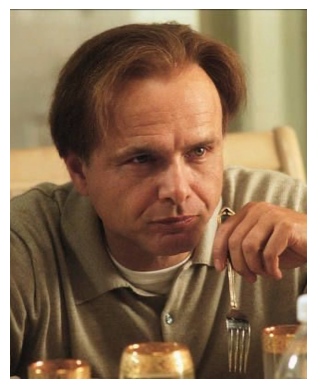

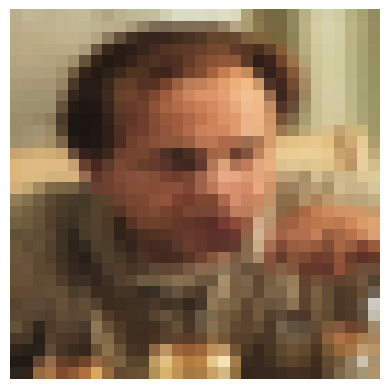

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0052512..2.300854].


dog


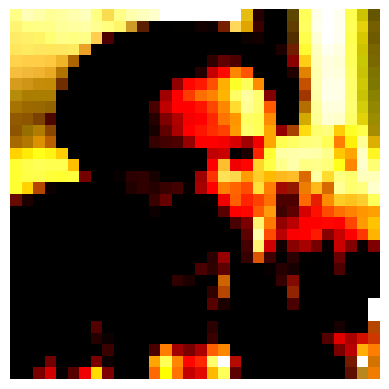

In [18]:
target_path = select_target(inputs_dir)
target = Image.open(target_path)
plot_figure(target)

image_tensor = downsample(target)
plot_figure(image_tensor)

normalize_tensor = model_normalize(target)
prediction = make_prediction(normalize_tensor.unsqueeze(0))
print(prediction)
plot_figure(normalize_tensor)

In [19]:
inputs_dir = Path(inputs_dir)
images = [image for image in sorted(list(inputs_dir.iterdir())) if image.suffixes in [['.jpeg'], ['.jpg']]]

gif_paths = []
for image_path in tqdm(images):
    target = Image.open(image_path)
    history = tune_attack(target, target_class, pixel_budget = pixel_budget)
    gif_paths.append(animate_evolution(image_path, history))


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Optimizing:   0%|          | 0/50 [00:00<?, ?gen/s]

Optimizing:   0%|          | 0/50 [00:00<?, ?gen/s]

Optimizing:   0%|          | 0/50 [00:00<?, ?gen/s]

...

Optimizing:   0%|          | 0/50 [00:00<?, ?gen/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Optimizing:   0%|          | 0/50 [00:00<?, ?gen/s]

Optimizing:   0%|          | 0/50 [00:00<?, ?gen/s]

Optimizing:   0%|          | 0/50 [00:00<?, ?gen/s]